<div style="border-left: 6px solid #00cfff;
background: linear-gradient(90deg, #0f2027, #203a43);
padding: 20px;
color: #b3f5ff;
font-size: 40px;
font-family: 'Segoe UI', sans-serif;
font-weight: 400;
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<b style="color: #00cfff;">⚡</b>
<span style="color: #ffffff;">Exercícios Aprendizado Profundo</span>
</div>

<div style="border-left: 6px solid #00cfff;
background: linear-gradient(90deg, #0f2027, #203a43);
padding: 20px;
color: #b3f5ff;
font-size: 22px;
font-family: 'Segoe UI', sans-serif;
font-weight: 300;
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">3) Implemente e treine uma Rede Neural Convolucional (CNN) para resolver o problema de
classificação de objetos em imagens, utilizando a base de dados CIFAR-10, disponível em:
https://www.cs.toronto.edu/~kriz/cifar.html.
Apresente a curva do erro médio ao longo do treinamento, bem como a matriz de confusão do
modelo avaliado sobre o conjunto de testes.</span>
</div>

In [263]:
#PACOTES
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [264]:
#função dada em https://www.cs.toronto.edu/~kriz/cifar.html para puxar os dados
def load_data(file):
    with open(file, "rb") as fo:
        data_dict = pickle.load(fo, encoding="bytes")
    return data_dict


In [265]:
import os
current_dir = os.path.abspath(os.getcwd())

path1  = "cifar_data/data_batch_1"
path2  = "cifar_data/data_batch_2"
path3  = "cifar_data/data_batch_3"
path4  = "cifar_data/data_batch_4"
path5  = "cifar_data/data_batch_5"

data1 = load_data(path1)
data2 = load_data(path2)
data3 = load_data(path3)
data4 = load_data(path4)
data5 = load_data(path5)

images1 = data1[b"data"]
images2 = data2[b"data"]
images3 = data3[b"data"]
images4 = data4[b"data"]
images5 = data5[b"data"]

# labels dos 5 batches
labels1 = np.array(data1[b"labels"])
labels2 = np.array(data2[b"labels"])
labels3 = np.array(data3[b"labels"])
labels4 = np.array(data4[b"labels"])
labels5 = np.array(data5[b"labels"])

X = np.concatenate([images1, images2, images3, images4, images5], axis=0)   # (50000, 3072)
y = np.concatenate([labels1, labels2, labels3, labels4, labels5], axis=0)   # (50000,)


classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


C:\Users\Usuario\AppData\Local\Temp\ipykernel_12844\876529372.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data_dict = pickle.load(fo, encoding="bytes")


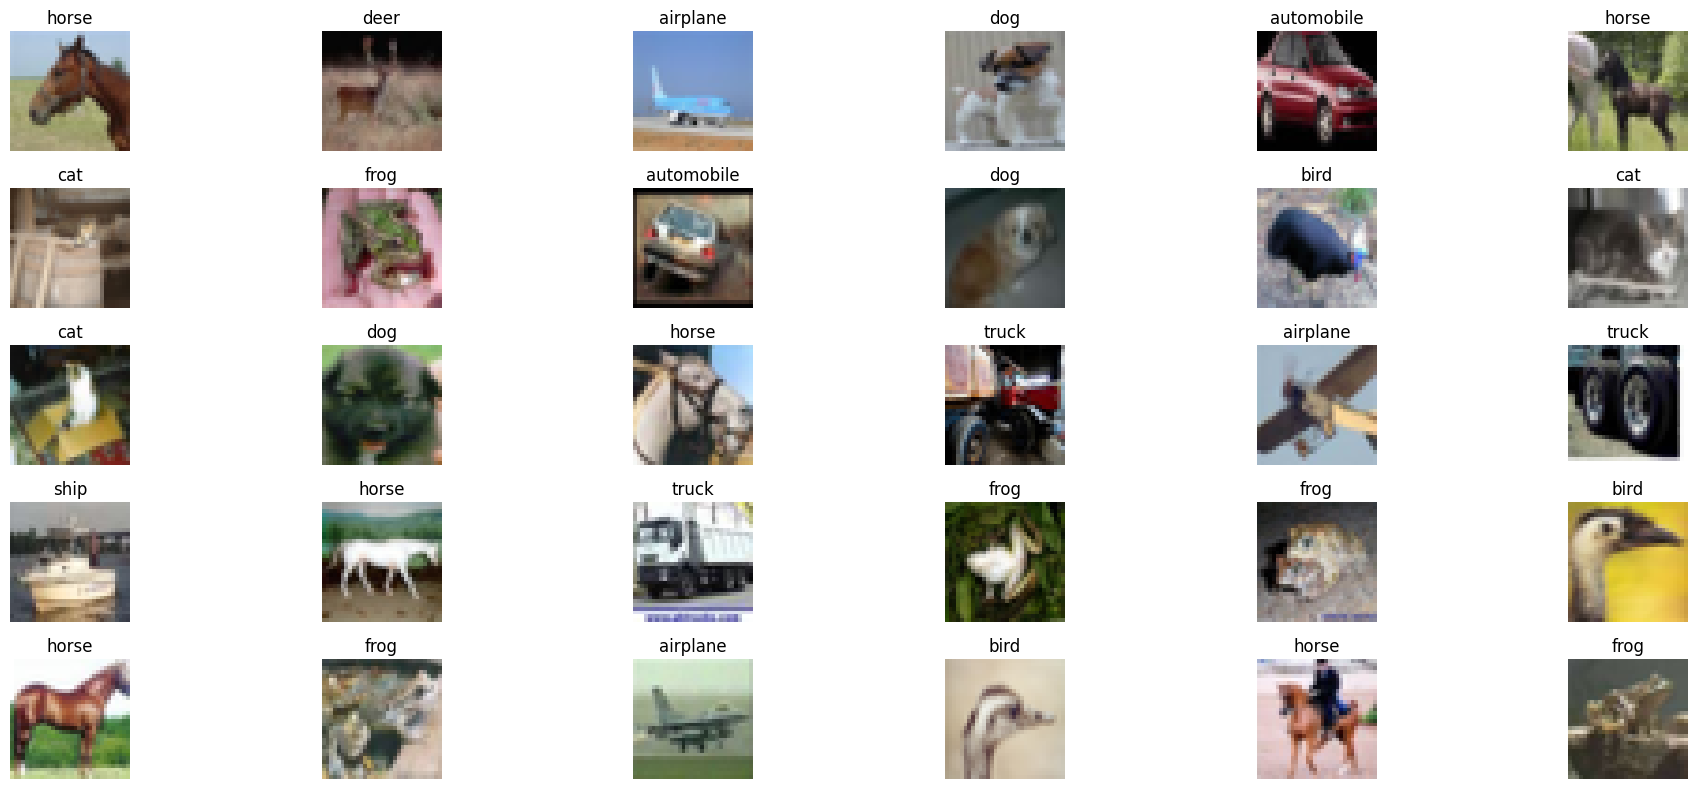

In [266]:
#PLOTANDO 20  figuras aleatórias
plt.figure(figsize=(20,8))

import random
figures = [random.randint(1, 40000) for _ in range(30)]
i = 0
for f in figures:
    plt.subplot(5, 6, i + 1)  
    img = X[f].reshape(3,32,32).transpose(1, 2, 0)
    plt.imshow(img)
    title = y[f]
    plt.title(f'{classes[title]}')
    plt.axis('off')            #
    i += 1
plt.tight_layout()
plt.show()

<div style="border-left: 6px solid #00cfff;
background: linear-gradient(90deg, #0f2027, #203a43);
padding: 20px;
color: #b3f5ff;
font-size: 22px;
font-family: 'Segoe UI', sans-serif;
font-weight: 300;
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">
Os labels são 10: 
<ul>
       <li>Avião
       <li>Automóvel
       <li>Pássaro
       <li>Gato
       <li>Veado
       <li>Cachorro
       <li>Sapo
       <li>Cavalo
       <li>Navio
       <li>Caminhão
    </ul>
</span>
</div>

In [267]:
from sklearn.model_selection import train_test_split
import tensorflow as tf


In [268]:
#SEPARANDO TREINO E TESTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
X_test  = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

print("X train:", X_train.shape)  
print("X test:", X_test.shape)  
print("y train:", y_train.shape)  
print("y test:", y_test.shape)  

X train: (40000, 32, 32, 3)
X test: (10000, 32, 32, 3)
y train: (40000,)
y test: (10000,)


In [269]:

X_train = X_train.astype("float32")
X_test  = X_test.astype("float32")

#definindo o batch
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(64).prefetch(tf.data.AUTOTUNE)
test_dataset  = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(64).prefetch(tf.data.AUTOTUNE)


In [270]:
#estou usando o formato flat
for data_batch, labels_batch in train_dataset:
    print(data_batch.shape)
    print(labels_batch.shape)
    print(data_batch[0].shape)
    break

(64, 32, 32, 3)
(64,)
(32, 32, 3)


In [271]:
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling
from keras.regularizers import l2


<div style="border-left: 6px solid #00cfff;
background: linear-gradient(90deg, #0f2027, #203a43);
padding: 20px;
color: #b3f5ff;
font-size: 22px;
font-family: 'Segoe UI', sans-serif;
font-weight: 300;
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">

Rede implementada com:
<ul>
    <li>Data augmentation
    <li>Convolução com padding, ou seja, adiciona zeros a matriz 32x32, para que o tamanho da imagem final seja o mesmo da inicial
    <li>Convolução com regularização
    <li>Normalização dos Batchs
    <li>Maxpooling 2x2: seleciona os pixels de maior intensidade dentro de cada regiao 2x2 da imagem -
</ul>


</span>
</div>

In [ ]:
#OneHotEncoder
y_train = keras.utils.to_categorical(y_train.ravel(), num_classes=10)
y_test  = keras.utils.to_categorical(y_test.ravel(),  num_classes=10)

weight_decay = 0.0001

data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.08),
    keras.layers.RandomTranslation(0.1, 0.1),
    keras.layers.RandomZoom(0.1),
])

model = keras.Sequential([
    keras.layers.Input(shape=(32,32,3)),
    keras.layers.Rescaling(1./255),
    data_augmentation,
    keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu',kernel_regularizer=l2(weight_decay), padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', kernel_regularizer=l2(weight_decay),padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2,2)),

    
    keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu', kernel_regularizer=l2(weight_decay), padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu', kernel_regularizer=l2(weight_decay), padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(128, kernel_size=(3,3), activation='relu', kernel_regularizer=l2(weight_decay), padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(128, kernel_size=(3,3), activation='relu', kernel_regularizer=l2(weight_decay),padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2,2)),

    # keras.layers.Conv2D(256, kernel_size=(3,3), activation='relu', kernel_regularizer=l2(weight_decay), padding='same'),
    # # keras.layers.BatchNormalization(),
    # keras.layers.Conv2D(256, kernel_size=(3,3), activation='relu', kernel_regularizer=l2(weight_decay),padding='same'),
    # # keras.layers.BatchNormalization(),
    # keras.layers.MaxPooling2D((2,2)),
    
    keras.layers.Flatten(),
    keras.layers.Dropout(rate=0.25),
    keras.layers.Dense(10, input_shape=(32,32,3), activation='softmax')
])


METRICS = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall')
]


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  
    metrics=METRICS
)

model.summary()


c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_16 (Rescaling)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_28 (Sequential)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_66 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 309,290 (1.18 MB)

 Trainable params: 308,394 (1.18 MB)

 Non-trainable params: 896 (3.50 KB)

In [273]:
history = model.fit(X_train, y_train,
                    epochs=30,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=2)


Epoch 1/30
1000/1000 - 65s - 65ms/step - accuracy: 0.3798 - loss: 1.9973 - precision: 0.4766 - recall: 0.2432 - val_accuracy: 0.2819 - val_loss: 3.1714 - val_precision: 0.3080 - val_recall: 0.2470
Epoch 2/30
1000/1000 - 64s - 64ms/step - accuracy: 0.5026 - loss: 1.5237 - precision: 0.6202 - recall: 0.3676 - val_accuracy: 0.5142 - val_loss: 1.5419 - val_precision: 0.6053 - val_recall: 0.4340
Epoch 3/30
1000/1000 - 67s - 67ms/step - accuracy: 0.5740 - loss: 1.2960 - precision: 0.6936 - recall: 0.4540 - val_accuracy: 0.6181 - val_loss: 1.1990 - val_precision: 0.7072 - val_recall: 0.5505
Epoch 4/30
1000/1000 - 69s - 69ms/step - accuracy: 0.6187 - loss: 1.1722 - precision: 0.7272 - recall: 0.5048 - val_accuracy: 0.6202 - val_loss: 1.3258 - val_precision: 0.6993 - val_recall: 0.5641
Epoch 5/30
1000/1000 - 70s - 70ms/step - accuracy: 0.6481 - loss: 1.0943 - precision: 0.7535 - recall: 0.5414 - val_accuracy: 0.6549 - val_loss: 1.1553 - val_precision: 0.7326 - val_recall: 0.5922
Epoch 6/30
1000

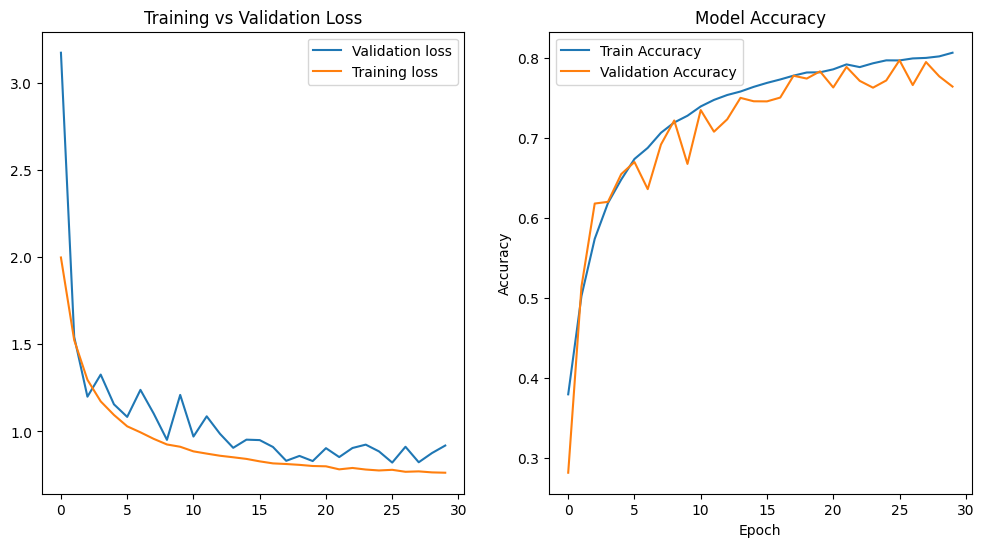

In [274]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.plot(history.history['val_loss'], label="Validation loss")
plt.plot(history.history['loss'], label="Training loss")
plt.legend()
plt.title("Training vs Validation Loss")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


In [275]:
print(y_train.shape, y_test.shape)      # esperado: (N, 10)
print(np.unique(np.argmax(y_test, axis=1)))  # esperado: classes 0..9

(40000, 10) (10000, 10)
[0 1 2 3 4 5 6 7 8 9]


In [276]:

nimages = 10000
idx = np.random.choice(X_test.shape[0], nimages, replace=False)
y_pred = model.predict(X_test[idx]).argmax(axis=1)
y_true = y_test[idx].argmax(axis=1)

print('Test Accuracy = %.2f' % (100.0 * np.mean(y_pred == y_true)))

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
Test Accuracy = 76.25


In [277]:
from sklearn.metrics import classification_report
import numpy as np

# Probabilidades -> classe prevista
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# y_test está one-hot, converte para rótulo inteiro
y_true_classes = np.argmax(y_test, axis=1)

print(
    classification_report(
        y_true_classes,
        y_pred_classes,
        target_names=classes,
        digits=4,
        zero_division=0
    )
)


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
              precision    recall  f1-score   support

    airplane     0.7810    0.8284    0.8040       973
  automobile     0.7630    0.9602    0.8503       979
        bird     0.8162    0.6854    0.7451      1030
         cat     0.6341    0.6217    0.6278      1023
        deer     0.7929    0.6935    0.7399       933
         dog     0.8944    0.4256    0.5768      1015
        frog     0.5534    0.9618    0.7026       996
       horse     0.8318    0.8410    0.8364       994
        ship     0.9548    0.7886    0.8638      1017
       truck     0.8681    0.8288    0.8480      1040

    accuracy                         0.7625     10000
   macro avg     0.7890    0.7635    0.7595     10000
weighted avg     0.7896    0.7625    0.7592     10000



313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


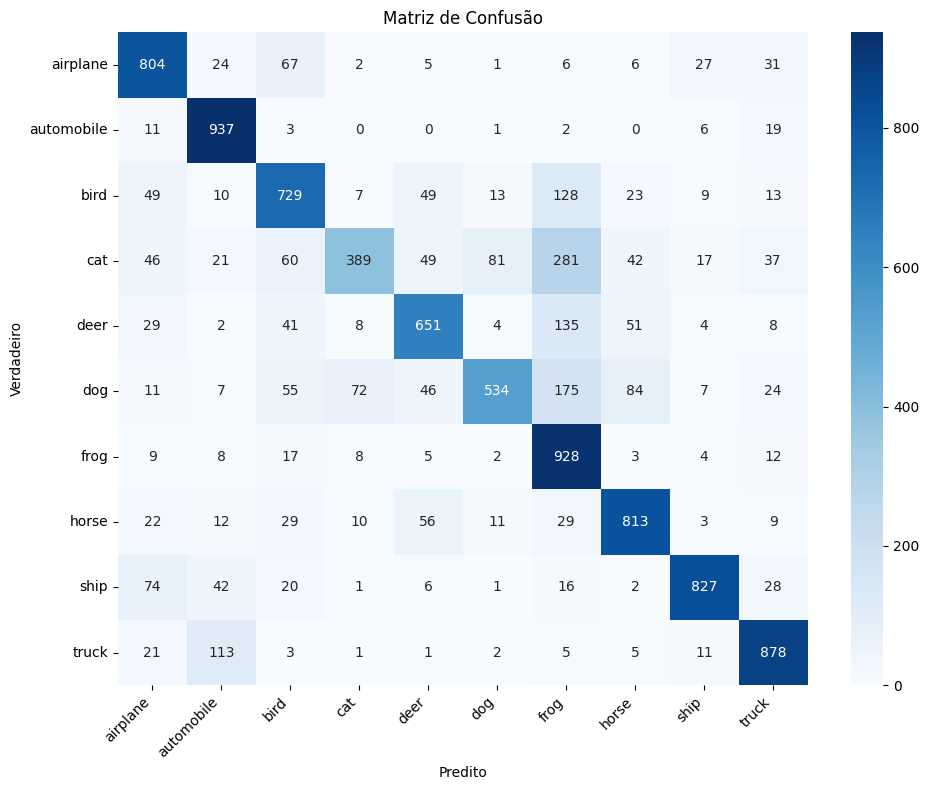

In [278]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Se ainda não tiver:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)  # y_test one-hot

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

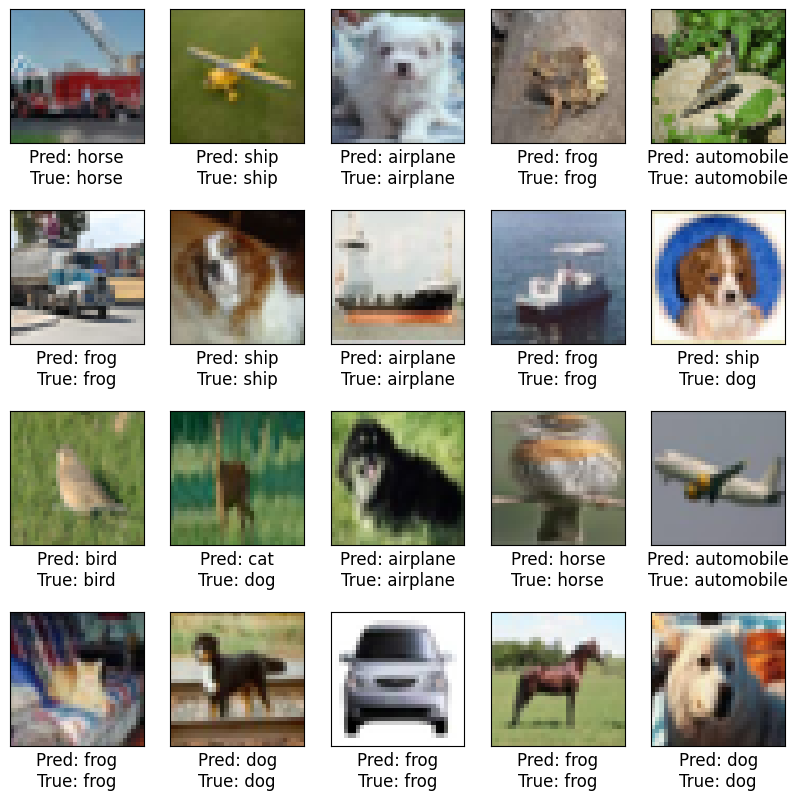

In [279]:
fig, axes = plt.subplots(4, 5, figsize=(10, 10))
image_size = 32
num_channels = 3



for i, ax in enumerate(axes.flat):
    img = X_test[idx[i]] / 255.0
    ax.imshow(img)
    pred_class = classes[y_pred_classes[i]]
    true_class = classes[y_true_classes[i]]
    ax.set_xlabel('Pred: {}\nTrue: {}'.format(pred_class, true_class), fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])